In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option("display.max_columns", 100)

In [4]:
DATA_DIR = "../02_data_cleaning/data/clean/" 

orders = pd.read_csv(DATA_DIR + "Olist_Orders.csv")

In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Unnamed: 0                     99441 non-null  int64 
 1   order_id                       99441 non-null  object
 2   customer_id                    99441 non-null  object
 3   order_status                   99441 non-null  object
 4   order_purchase_timestamp       99441 non-null  object
 5   order_approved_at              99281 non-null  object
 6   order_delivered_carrier_date   97658 non-null  object
 7   order_delivered_customer_date  96476 non-null  object
 8   order_estimated_delivery_date  99441 non-null  object
 9   was_delivered                  99441 non-null  bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 6.9+ MB


In [6]:
orders = pd.read_csv(DATA_DIR + "Olist_Orders.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

order_items = pd.read_csv(DATA_DIR + "Olist_Order_Items.csv")
payments = pd.read_csv(DATA_DIR + "Olist_Order_Payments.csv")
reviews = pd.read_csv(DATA_DIR + "Olist_Order_Reviews.csv")
products = pd.read_csv(DATA_DIR + "Olist_Products.csv")
customers = pd.read_csv(DATA_DIR + "Olist_Customers.csv")
sellers = pd.read_csv(DATA_DIR + "Olist_Sellers.csv")
geolocation = pd.read_csv(DATA_DIR + "Olist_Geolocation.csv")

tables = {
    "orders": orders, "order_items": order_items, "payments": payments,
    "reviews": reviews, "products": products, "customers": customers,
    "sellers": sellers, "geolocation": geolocation
}

for name, df in tables.items():
    shape_str = str(df.shape)
    print(f"| {name:15s} | shape={shape_str:12s} |")

| orders          | shape=(99441, 10)  |
| order_items     | shape=(112650, 8)  |
| payments        | shape=(103886, 6)  |
| reviews         | shape=(99224, 9)   |
| products        | shape=(32950, 10)  |
| customers       | shape=(99441, 6)   |
| sellers         | shape=(3095, 5)    |
| geolocation     | shape=(1000163, 6) |


---
## Phase 1 — Missingness & Integrity Audit

Goal: to know exactly what's missing and *why* before any visualization. Some NaNs are structural
(e.g. `order_delivered_customer_date` is null for canceled/undelivered orders) — those aren't
errors, they're a category worth keeping. Others may be leftover cleaning gaps worth flagging.


In [9]:
def missingness_report(df, name):
    miss = df.isna().sum()
    pct = (miss / len(df)*100).round(2)
    report = pd.DataFrame({"n_missing": miss, "pct_missing": pct})
    report = report[report["n_missing"] > 0].sort_values("pct_missing", ascending=False)
    if not report.empty:
        print(f"--- {name} ---")
        print(report)
        print()
    return report

In [10]:
for name, df in tables.items():
    missingness_report(df, name)

--- orders ---
                               n_missing  pct_missing
order_delivered_customer_date       2965         2.98
order_delivered_carrier_date        1783         1.79
order_approved_at                    160         0.16

--- reviews ---
                        n_missing  pct_missing
review_comment_title        87666        88.35
review_comment_message      58292        58.75

--- products ---
                            n_missing  pct_missing
product_name_lenght               609         1.85
product_description_lenght        609         1.85
product_photos_qty                609         1.85
product_weight_g                    1         0.00
product_length_cm                   1         0.00
product_height_cm                   1         0.00
product_width_cm                    1         0.00



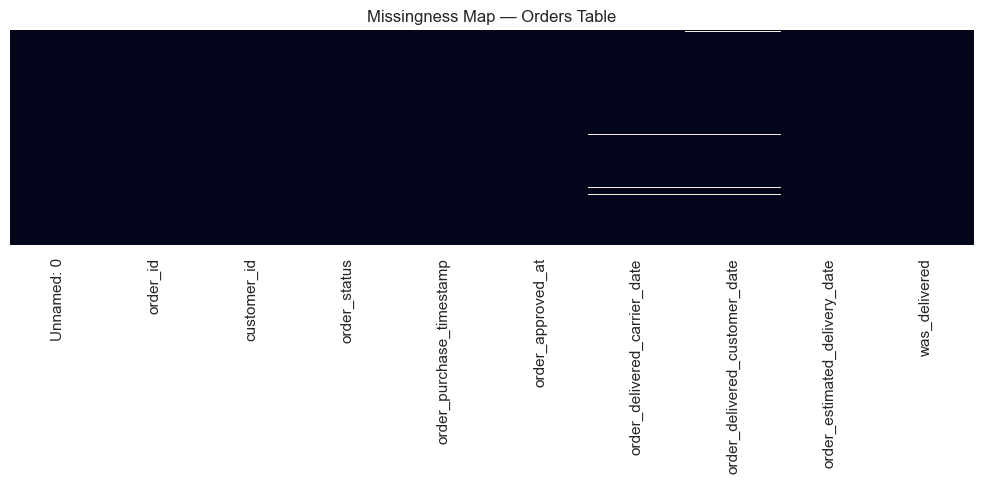

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(orders.isna(), cbar=False, yticklabels=False, cmap="rocket")
ax.set_title("Missingness Map — Orders Table")
plt.tight_layout()
plt.show()

In [13]:
orders.groupby('order_status')['order_delivered_customer_date'].apply(lambda s: s.isna().mean()).round(3)

order_status
approved       1.00
canceled       0.99
created        1.00
delivered      0.00
invoiced       1.00
processing     1.00
shipped        1.00
unavailable    1.00
Name: order_delivered_customer_date, dtype: float64

# Phase 2 - Univariate Exploration

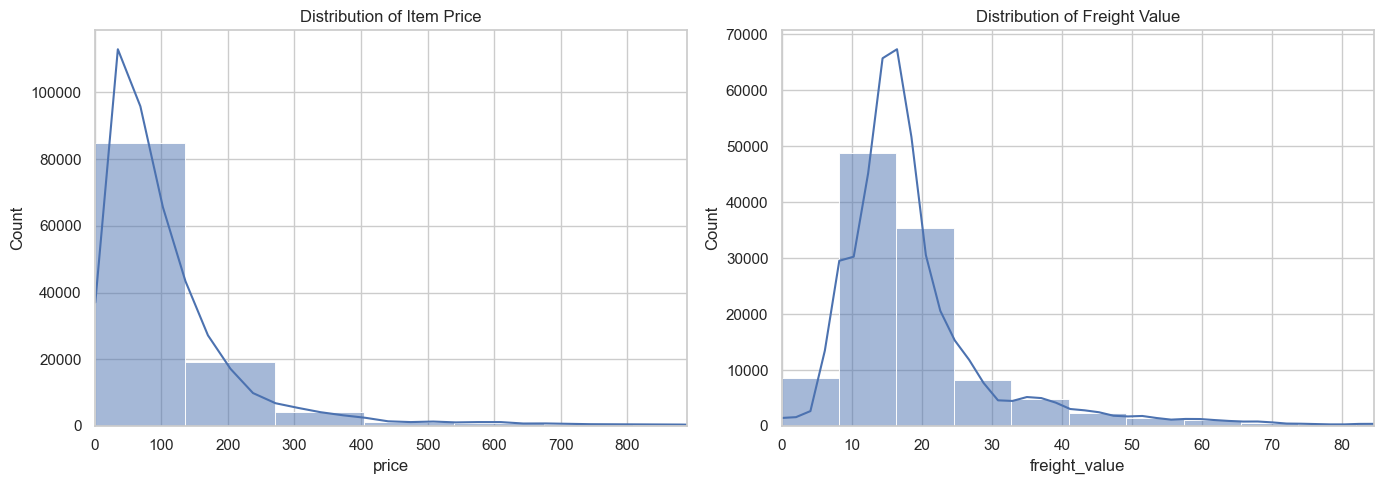

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(order_items['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Item Price')
axes[0].set_xlim(0, order_items['price'].quantile(0.99))

sns.histplot(order_items["freight_value"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Freight Value")
axes[1].set_xlim(0, order_items["freight_value"].quantile(0.99))
plt.tight_layout()
plt.show()

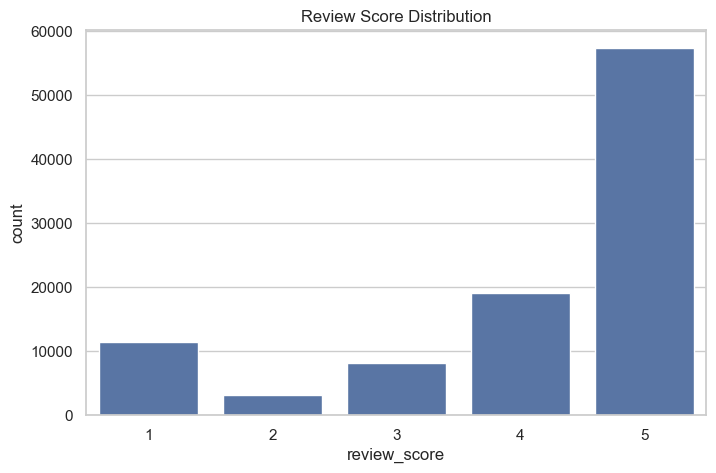

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=reviews, x='review_score', ax=ax)
ax.set_title('Review Score Distribution')
plt.show()

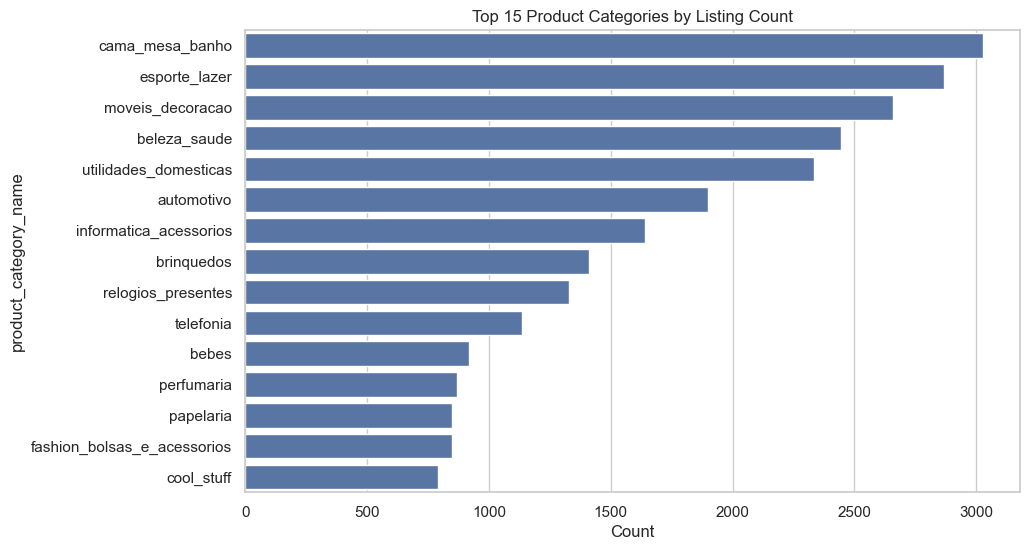

In [22]:
top_categories = products['product_category_name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax)
ax.set_title('Top 15 Product Categories by Listing Count')
ax.set_xlabel('Count')
plt.show()

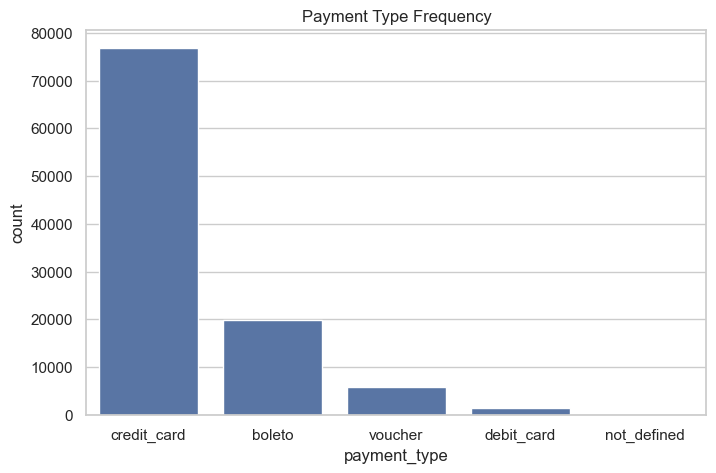

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=payments, x='payment_type', order=payments['payment_type'].value_counts().index, ax=ax)
ax.set_title('Payment Type Frequency')
plt.show()